# XGBoost–FNN Hybrid Model for Wind Speed Forecasting
## Multivariate Standalone Optimal Model with Residual Correction
### Sections: Original Model | Grid Search | Randomized Search | Optuna


## 1. Installing Required Packages

In [ ]:
# INSTALLING REQUIRED PACKAGES
!pip install statsmodels optuna tabulate xgboost --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.0 MB/s eta 0:00:00


## 2. Imports & Global Settings

In [ ]:
# Standard libraries
import sys
import os
import warnings
import random
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np   # Numerical operations
import pandas as pd  # Data manipulation and analysis

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV,
                                     RandomizedSearchCV)

# Neural network
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

# Permutation importance
from sklearn.inspection import permutation_importance

# Scipy distributions (used in Randomized Search)
from scipy.stats import uniform

# XGBoost
import xgboost as xgb

# Optuna (Bayesian hyperparameter optimisation)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose trial logs

# ── Global random seed (set once here; reused throughout) ──────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Global random seed set to {RANDOM_SEED}")


Global random seed set to 42


## 3. Loading the Dataset

In [ ]:
# =============================================================================
# LOADING THE DATASET
# Dataset source:
#   https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
#   https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"   # Variable Set 2 dataset
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')

# Drop the raw date columns (now encoded in the index)
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())


Dataset loaded successfully.
Shape: (4015, 14)

First 5 rows:


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66



Column names:
['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


## 4. Primary Train–Test Split (80 / 20, Time-Based)

In [ ]:
# =============================================================================
# Train-test split — 80% first observations for training, last 20% for testing.
# Temporal ordering is preserved; no shuffling is applied.
# =============================================================================

X = df.drop(columns=['WS10M'])  # Features
y = df['WS10M']                 # Target: wind speed

split_index = int(len(X) * 0.8)  # 80% training, 20% testing

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  ({split_index} samples)")
print(f"Test set      : {X_test.shape}  ({len(X) - split_index} samples)")
print(f"\nTrain period: {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test period : {X_test.index[0].date()}  →  {X_test.index[-1].date()}")


Total samples : 4015
Training set  : (3212, 13)  (3212 samples)
Test set      : (803, 13)  (803 samples)

Train period: 2013-01-03  →  2021-10-19
Test period : 2021-10-20  →  2023-12-31


## 5. XGBoost Primary Model (Optuna-Optimised Parameters)
The XGBoost model was previously optimised with Optuna and produced the
following standalone optimal performance on wind-speed forecasting:

| Method | Train MSE | Test MSE | Train MAE | Test MAE | Train RMSE | Test RMSE | Train MAPE (%) | Test MAPE (%) | Train R² | Test R² |
|--------|-----------|----------|-----------|----------|------------|-----------|----------------|---------------|----------|---------|
| Optuna | 0.211530  | 0.527328 | 0.360631  | 0.551346 | 0.459923   | 0.726173  | 9.983644       | 14.987060     | 0.916036 | 0.781323|


In [ ]:
# =============================================================================
# XGBoost with time-series cross-validation (primary model).
# Best parameters obtained from a prior Optuna optimisation run.
# The model is fitted once on X_train; residuals over the full dataset are
# used to train the FNN correction layer in subsequent sections.
# =============================================================================
#Best Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'min_child_weight': 5, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084}
# ── Best parameters from Optuna ─────────────────────────────────────────────
Best_Parameters = {
    'n_estimators':    300,
    'max_depth':       6,
    'learning_rate':   0.02017215364230889,
    'gamma':           0.019237778052053844,
    'subsample':       0.618408743715084,
    'min_child_weight': 5
}

# Initialise XGBRegressor with optimal parameters
best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on training data only (no leakage of test information)
best_xgb.fit(X_train, y_train)
print(f"XGBoost model fitted.  Parameters: {Best_Parameters}")

# ── Predictions ──────────────────────────────────────────────────────────────
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# ── Evaluation metrics ───────────────────────────────────────────────────────
xgb_train_mse  = mean_squared_error(y_train, y_train_pred_xgb)
xgb_test_mse   = mean_squared_error(y_test,  y_test_pred_xgb)
xgb_train_mae  = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_test_mae   = mean_absolute_error(y_test,  y_test_pred_xgb)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_test_rmse  = np.sqrt(xgb_test_mse)
xgb_train_mape = np.mean(np.abs((y_train - y_train_pred_xgb) / y_train)) * 100
xgb_test_mape  = np.mean(np.abs((y_test  - y_test_pred_xgb)  / y_test))  * 100
xgb_train_r2   = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2    = r2_score(y_test,  y_test_pred_xgb)

print(f"\nTrain MSE:  {xgb_train_mse:.4f}  | Test MSE:  {xgb_test_mse:.4f}")
print(f"Train MAE:  {xgb_train_mae:.4f}  | Test MAE:  {xgb_test_mae:.4f}")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Test RMSE: {xgb_test_rmse:.4f}")
print(f"Train MAPE: {xgb_train_mape:.4f}%| Test MAPE: {xgb_test_mape:.4f}%")
print(f"Train R²:   {xgb_train_r2:.4f}  | Test R²:   {xgb_test_r2:.4f}")

# ── Summary table (Plotly) ───────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Parameter/Metric': list(Best_Parameters.keys()) +
                        ['Train MSE', 'Test MSE', 'Train MAE', 'Test MAE',
                         'Train RMSE', 'Test RMSE', 'Train MAPE (%)',
                         'Test MAPE (%)', 'Train R²', 'Test R²'],
    'Value': list(Best_Parameters.values()) +
             [xgb_train_mse, xgb_test_mse, xgb_train_mae, xgb_test_mae,
              xgb_train_rmse, xgb_test_rmse, xgb_train_mape, xgb_test_mape,
              xgb_train_r2, xgb_test_r2]
})
summary_df['Value'] = summary_df['Value'].apply(lambda x: f"{x:.6f}")

fig_table = go.Figure(go.Table(
    header=dict(
        values=['<b>Parameter / Metric</b>', '<b>Value</b>'],
        fill_color='steelblue',
        font=dict(color='white', size=13),
        align='left'
    ),
    cells=dict(
        values=[summary_df['Parameter/Metric'], summary_df['Value']],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(summary_df))]],
        align='left'
    )
))
fig_table.update_layout(
    title="XGBoost Optimal Parameters & Model Performance Metrics",
    template="plotly_white",
    height=600
)
fig_table.show()


XGBoost model fitted.  Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}

Train MSE:  0.2103  | Test MSE:  0.5259
Train MAE:  0.3590  | Test MAE:  0.5495
Train RMSE: 0.4586 | Test RMSE: 0.7252
Train MAPE: 9.9187%| Test MAPE: 14.9222%
Train R²:   0.9165  | Test R²:   0.7819


## 6. Out-of-Fold (Train) & Out-of-Sample (Test) XGBoost Residuals

Training-set residuals are now generated **out-of-fold** via the same
5-fold `TimeSeriesSplit` used elsewhere, so the FNN in Section 7 is trained
on residuals with the same statistical character as the true out-of-sample
test residuals it must correct at deployment (see code comments below for
the full rationale).

In [ ]:
# =============================================================================
# Generate OUT-OF-FOLD (OOF) residuals on the training set, and true
# out-of-sample residuals on the held-out test set.
#
# WHY THIS CHANGED
# -----------------
# Previously: best_xgb (fit once on X_train) was used to predict over the
# FULL dataset (X). For the training rows this means the residual used to
# train the FNN was an IN-SAMPLE residual -- XGBoost had already seen those
# exact (X_train, y_train) pairs while fitting. In-sample residuals of a
# boosted-tree ensemble are systematically smaller, and differently
# distributed, than the residuals the model produces on data it has never
# seen. So the FNN residual-correction model was being trained on an easy,
# unrepresentative target -- one that does not match the out-of-sample
# residuals it actually has to correct at test time. This target/deployment
# mismatch is a likely explanation for the modest hybrid gains reported.
#
# FIX
# ---
# For the TRAINING period: use the same TimeSeriesSplit(n_splits=5) scheme
# already used elsewhere in this notebook. On each fold, refit a model with
# best_xgb's hyperparameters on that fold's training block only, and predict
# on that fold's held-out validation block. Stacking these out-of-fold (OOF)
# predictions gives every training-set residual the same "unseen data"
# status as a genuine test-set residual, so the FNN now trains on a target
# whose distribution matches what it will see in deployment.
#
# For the TEST period: unchanged -- best_xgb (fit once on the full X_train)
# predicts on X_test, which was already out-of-sample.
#
# NOTE ON FOLD 1: TimeSeriesSplit's first fold has no preceding validation
# block, so its training rows can never receive an OOF prediction (there is
# no earlier model to validate them against). Those rows are left as NaN
# here and dropped before FNN training in Section 7. This is the standard,
# honest way to handle OOF generation in time series -- fabricating a
# residual for a block the model was never validated against would just
# reintroduce a milder version of the same leakage.
# =============================================================================

from sklearn.base import clone

tscv_resid = TimeSeriesSplit(n_splits=5)

# One out-of-fold prediction per training-set row; NaN where no fold's
# validation block covers that row (see NOTE ON FOLD 1 above)
oof_pred_train = np.full(len(X_train), np.nan)

print("Generating out-of-fold residuals on the training set:")
for fold_num, (tr_idx, val_idx) in enumerate(tscv_resid.split(X_train), start=1):
    # Fresh model, same hyperparameters as best_xgb, fit ONLY on this fold's
    # training block -- it has not seen this fold's validation block
    fold_model = clone(best_xgb)
    fold_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_pred_train[val_idx] = fold_model.predict(X_train.iloc[val_idx])
    print(f"  Fold {fold_num}: trained on {len(tr_idx):4d} rows -> "
          f"OOF-predicted {len(val_idx):4d} rows")

# True out-of-sample predictions on the test set (best_xgb, fit on the full
# X_train, has never seen X_test -- this part needs no change)
y_test_pred_for_resid = best_xgb.predict(X_test)

# ── Assemble predictions/residuals back onto the full dataframe ─────────────
y_pred_full_xgb = np.concatenate([oof_pred_train, y_test_pred_for_resid])
df['Pred_XGB_Optuna'] = y_pred_full_xgb
df['Residual']        = df['WS10M'] - df['Pred_XGB_Optuna']

n_oof_missing = int(np.isnan(oof_pred_train).sum())
print(f"\nTraining rows without an OOF residual (Fold 1's initial training "
      f"block): {n_oof_missing} -- will be dropped before FNN training "
      f"(see Section 7).")
print("Predictions and residuals added to dataframe.")
print(df[['WS10M', 'Pred_XGB_Optuna', 'Residual']].head(10))

# Backup the enriched dataframe (used by all hybrid model sections below)
df_backup = df.copy()

# ── Visualise actual vs predicted + residuals ────────────────────────────────
# (NaN residuals for the undefined Fold-1 training block will simply show as
# a gap in the residual trace below, rather than a fabricated value.)
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Actual vs Predicted Wind Speed (XGB Optuna)", "Residuals"),
    shared_xaxes=True,
    vertical_spacing=0.12
)

fig.add_trace(go.Scatter(
    x=df.index, y=df['WS10M'],
    mode='lines', name='Actual WS10M',
    line=dict(color='steelblue', width=1.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df.index, y=df['Pred_XGB_Optuna'],
    mode='lines', name='Predicted (XGB Optuna)',
    line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df.index, y=df['Residual'],
    mode='lines', name='Residual',
    line=dict(color='crimson', width=1)
), row=2, col=1)

fig.add_hline(y=0, line_dash="dash", line_color="black", row=2, col=1)

fig.update_layout(
    height=700, template="plotly_white",
    title="XGBoost Optuna — OOF Train Residuals + Out-of-Sample Test Residuals",
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1)
)
fig.update_yaxes(title_text="Wind Speed (m/s)", row=1, col=1)
fig.update_yaxes(title_text="Residual",         row=2, col=1)
fig.update_xaxes(title_text="Date",             row=2, col=1)
fig.show()

# Save XGBoost predictions to CSV
df.to_csv('XGB_Primary_Model_Prediction.csv', index=True)
print("\nSaved to 'XGB_Primary_Model_Prediction.csv'")


Generating out-of-fold residuals on the training set:
  Fold 1: trained on  537 rows -> OOF-predicted  535 rows
  Fold 2: trained on 1072 rows -> OOF-predicted  535 rows
  Fold 3: trained on 1607 rows -> OOF-predicted  535 rows
  Fold 4: trained on 2142 rows -> OOF-predicted  535 rows
  Fold 5: trained on 2677 rows -> OOF-predicted  535 rows

Training rows without an OOF residual (Fold 1's initial training block): 537 -- will be dropped before FNN training (see Section 7).
Predictions and residuals added to dataframe.
            WS10M  Pred_XGB_Optuna  Residual
Date                                        
2013-01-03   4.75              NaN       NaN
2013-01-04   5.74              NaN       NaN
2013-01-05   5.79              NaN       NaN
2013-01-06   4.52              NaN       NaN
2013-01-07   4.66              NaN       NaN
2013-01-08   3.61              NaN       NaN
2013-01-09   4.19              NaN       NaN
2013-01-10   5.41              NaN       NaN
2013-01-11   5.95         


Saved to 'XGB_Primary_Model_Prediction.csv'


## 7. Residual Autocorrelation (ACF) Diagnostics

The FNN residual-correction model receives the same exogenous features
XGBoost already used, so there is little genuinely new information left for
it to exploit there. One place a secondary model *can* find real signal is
in the residual series itself: if today's XGBoost error is correlated with
yesterday's (or the day before's), that is a pattern the exogenous features
alone cannot capture, but a lagged-residual feature can.

The plots and tests below use only the out-of-fold (train) / out-of-sample
(test) `'Residual'` column already computed in Section 6 -- never the old
in-sample residuals -- so this diagnostic can't reintroduce the leakage the
rest of this notebook was fixed to remove.


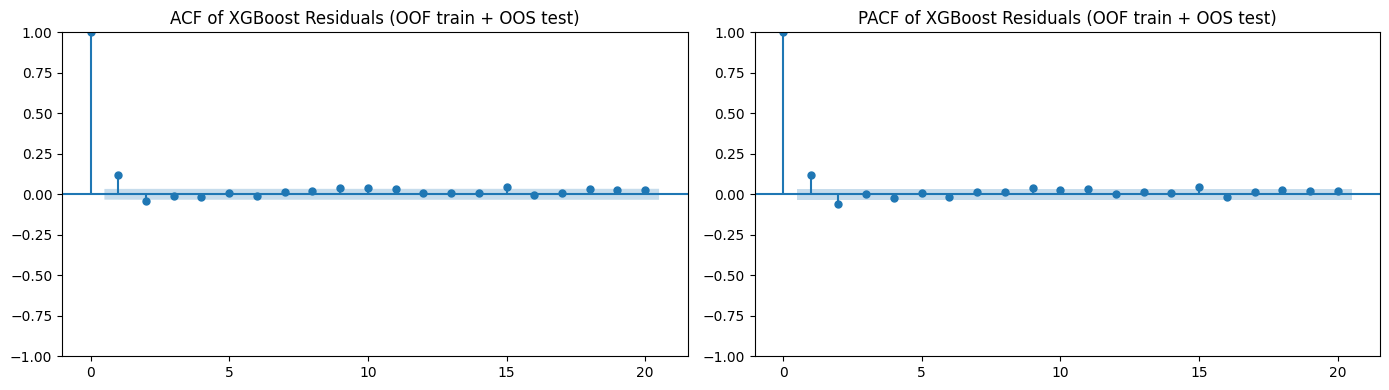

N = 3478 residuals | 95% significance threshold: |ACF| > 0.0332

Lag | ACF value | Significant?
  1 |    0.1170 |  <-- significant
  2 |   -0.0425 |  <-- significant
  3 |   -0.0110 |
  4 |   -0.0197 |
  5 |    0.0055 |
  6 |   -0.0109 |
  7 |    0.0126 |
  8 |    0.0211 |
  9 |    0.0419 |  <-- significant
 10 |    0.0376 |  <-- significant
 11 |    0.0340 |  <-- significant
 12 |    0.0072 |
 13 |    0.0100 |
 14 |    0.0087 |
 15 |    0.0444 |  <-- significant
 16 |   -0.0038 |
 17 |    0.0075 |
 18 |    0.0302 |
 19 |    0.0262 |
 20 |    0.0258 |

Statistically significant lags (95% level): [1, 2, 9, 10, 11, 15]

Ljung-Box test (H0: no autocorrelation up to the given lag):
      lb_stat     lb_pvalue
5   55.826496  8.823323e-11
10  69.389684  5.815016e-11
20  89.284626  9.884496e-11

(A p-value below 0.05 rejects H0 -- i.e. there IS significant autocorrelation up to that lag.)


In [ ]:
# =============================================================================
# RESIDUAL AUTOCORRELATION (ACF / PACF) DIAGNOSTICS
# -----------------------------------------------------------------------------
# WHAT THIS CELL DOES
#   Plots the autocorrelation (ACF) and partial autocorrelation (PACF) of the
#   OOF-train / OOS-test residual series, then flags which lags are
#   statistically significant using the standard large-sample white-noise
#   bound |ACF(k)| > 1.96/sqrt(N), and cross-checks with a Ljung-Box test.
#
# HOW TO READ IT
#   - ACF: correlation between the residual at time t and at time t-k.
#   - PACF: same, but with the effect of the intermediate lags removed --
#     useful for deciding how many lag features are actually independently
#     informative (e.g. if only lag 1 is significant in the PACF, adding a
#     lag-2 feature likely won't help beyond what lag-1 already captures).
#   - Shaded bands in the plots are the approximate 95% confidence interval
#     under the null hypothesis of no autocorrelation.
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf as acf_fn
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use only rows with a valid (non-NaN) residual -- excludes Fold 1's
# OOF-uncovered training block (see Section 6).
residual_series = df['Residual'].dropna()
N = len(residual_series)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residual_series, lags=20, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF of XGBoost Residuals (OOF train + OOS test)")
plot_pacf(residual_series, lags=20, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title("PACF of XGBoost Residuals (OOF train + OOS test)")
plt.tight_layout()
plt.show()

# ── Identify statistically significant lags (ACF) ────────────────────────────
n_lags = 20
threshold = 1.959964 / np.sqrt(N)  # standard 95% approx. bound for white noise
acf_vals = acf_fn(residual_series, nlags=n_lags, fft=False)

print(f"N = {N} residuals | 95% significance threshold: |ACF| > {threshold:.4f}\n")
print("Lag | ACF value | Significant?")
significant_lags = []
for lag in range(1, n_lags + 1):
    is_sig = abs(acf_vals[lag]) > threshold
    marker = "  <-- significant" if is_sig else ""
    print(f"{lag:>3} | {acf_vals[lag]:>9.4f} |{marker}")
    if is_sig:
        significant_lags.append(lag)

print(f"\nStatistically significant lags (95% level): {significant_lags}")

# ── Ljung-Box test: are residuals jointly autocorrelated up to lag k? ───────
lb_test = acorr_ljungbox(residual_series, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation up to the given lag):")
print(lb_test)
print("\n(A p-value below 0.05 rejects H0 -- i.e. there IS significant "
      "autocorrelation up to that lag.)")


## 8. FNN Residual Correction Model — Data Preparation


In [ ]:
# =============================================================================
# Feature set for FNN residual correction model
# -----------------------------------------------------------------------------
# Adds two new engineered features: Residual_lag1, Residual_lag2 -- the
# previous 1 and 2 days' OOF (train) / out-of-sample (test) XGBoost
# residuals. The ACF/PACF diagnostics above (Section 7) are used to decide
# whether these lags carry real signal; the features are included here so
# the FNN can exploit residual autocorrelation that the exogenous features
# alone cannot capture, since the FNN otherwise sees the same information
# XGBoost already used.
#
# WHY THIS IS NOT LEAKAGE: at forecast time for day t, the actual wind speed
# (and hence residual) for day t-1 and t-2 has already been observed -- these
# are genuine past values, not information from the future or from the row
# being predicted itself.
# =============================================================================

df['Residual_lag1'] = df['Residual'].shift(1)
df['Residual_lag2'] = df['Residual'].shift(2)
df_backup['Residual_lag1'] = df['Residual_lag1']
df_backup['Residual_lag2'] = df['Residual_lag2']
fnn_features = [
    'Residual_lag1', 'Residual_lag2'    # NEW: autoregressive residual features
]

X_res = df[fnn_features]  # Features for residual correction
y_res = df['Residual']    # Target: out-of-fold (train) / out-of-sample (test) residuals

# Same 80 / 20 temporal split as the primary model
split_index_res = int(len(X_res) * 0.8)

X_train_res = X_res.iloc[:split_index_res]
y_train_res = y_res.iloc[:split_index_res]
X_test_res  = X_res.iloc[split_index_res:]
y_test_res  = y_res.iloc[split_index_res:]

# ── Drop rows with any NaN feature or target ─────────────────────────────────
# Two independent sources of NaN now exist:
#   1. Fold 1 of TimeSeriesSplit(n_splits=5) has no preceding validation
#      block, so its training rows were never given an OOF residual
#      (Section 6) -- this affects y_train_res AND, via the .shift() above,
#      the Residual_lag1 / Residual_lag2 columns of the rows right after
#      that gap.
#   2. The very first 1-2 rows of the entire series have no lag-1/lag-2
#      residual to look back on.
# Filling either with a synthetic value would fabricate information or
# quietly leak, so these rows are dropped instead -- same policy as before,
# just applied to a slightly larger NaN footprint. Test rows are expected to
# lose none (their lag features look back into the already-valid tail of the
# training period), but the same check is applied for correctness.
train_valid_mask = X_train_res.notna().all(axis=1) & y_train_res.notna()
test_valid_mask  = X_test_res.notna().all(axis=1)  & y_test_res.notna()

n_dropped_train = int((~train_valid_mask).sum())
n_dropped_test  = int((~test_valid_mask).sum())

X_train_res = X_train_res.loc[train_valid_mask]
y_train_res = y_train_res.loc[train_valid_mask]
X_test_res  = X_test_res.loc[test_valid_mask]
y_test_res  = y_test_res.loc[test_valid_mask]

print(f"FNN residual model — training samples : {X_train_res.shape[0]} "
      f"(dropped {n_dropped_train} rows with a missing OOF residual and/or lag feature)")
print(f"FNN residual model — test samples     : {X_test_res.shape[0]} "
      f"(dropped {n_dropped_test} rows with a missing lag feature)")
print(f"Number of input features               : {X_train_res.shape[1]}")

# ── Shared helper functions ──────────────────────────────────────────────────
def evaluate(y_true, y_pred, label=""):
    """Print and return evaluation metrics for the residual model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2

def evaluate_performance(y_true, y_pred, set_name="Dataset"):
    """Evaluate and return metrics as a dictionary for the hybrid model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n--- {set_name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    return {'RMSE': rmse, 'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R²': r2}


FNN residual model — training samples : 2673 (dropped 539 rows with a missing OOF residual and/or lag feature)
FNN residual model — test samples     : 803 (dropped 0 rows with a missing lag feature)
Number of input features               : 2


## 9. FNN Residual Correction — Original Model (No Hyperparameter Optimisation)


--- Original FNN Residual Model Evaluation ---
Train (FNN Original) MSE:  0.5073
Train (FNN Original) RMSE: 0.7122
Train (FNN Original) MAE:  0.5459
Train (FNN Original) MAPE: 161.95%
Train (FNN Original) R²:   0.0276
Test  (FNN Original) MSE:  0.5176
Test  (FNN Original) RMSE: 0.7195
Test  (FNN Original) MAE:  0.5451
Test  (FNN Original) MAPE: 157.58%
Test  (FNN Original) R²:   0.0154
Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-FNN (Original) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7122
MSE:  0.5073
MAE:  0.5459
MAPE: 15.3363%
R²:   0.7987

--- Test Metrics ---
RMSE: 0.7195
MSE:  0.5176
MAE:  0.5451
MAPE: 14.8222%
R²:   0.7853


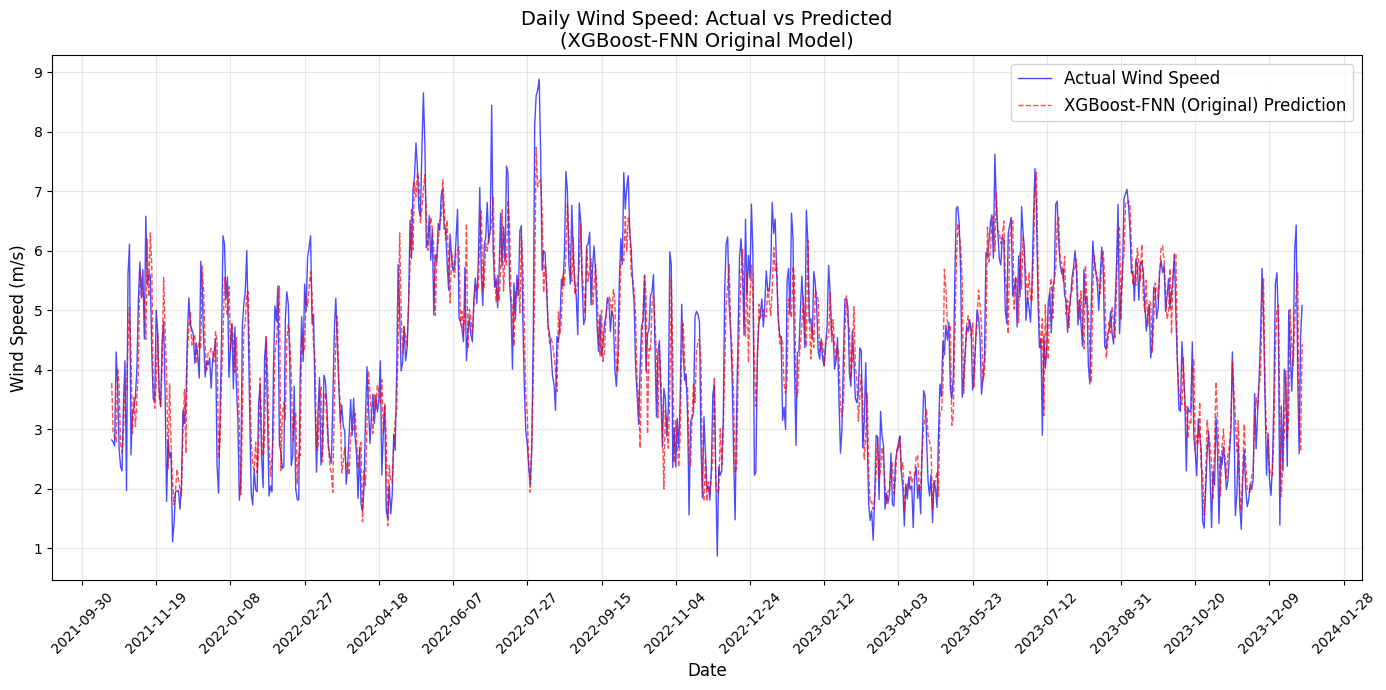

Saved to 'xgb_fnn_df_original.csv'


In [ ]:
# =============================================================================
# Section 1 — Original FNN model
# Default architecture: two hidden layers (100, 50 neurons).
# No hyperparameter search is performed in this section.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_original      = StandardScaler()
X_train_scaled_orig  = scaler_original.fit_transform(X_train_res)
X_test_scaled_orig   = scaler_original.transform(X_test_res)

# ── Model definition ─────────────────────────────────────────────────────────
fnn_original = MLPRegressor(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',             # ReLU activation function
    solver='adam',                 # Adam optimiser
    learning_rate='adaptive',      # Adaptive learning rate
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Fit on training residuals only
fnn_original.fit(X_train_scaled_orig, y_train_res)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_orig = fnn_original.predict(X_train_scaled_orig)
y_test_pred_orig  = fnn_original.predict(X_test_scaled_orig)

print("--- Original FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_orig, label="Train (FNN Original)")
evaluate(y_test_res,  y_test_pred_orig,  label="Test  (FNN Original)")

# ── Predict residuals on full dataset ────────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 8 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). MLPRegressor.predict() can't handle NaN input, so we predict only
# on the rows where every feature is valid, and leave the rest as NaN --
# consistent with 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
predicted_residuals_fnn_original_arr = np.full(len(X_res), np.nan)
predicted_residuals_fnn_original_arr[full_valid_mask.values] = fnn_original.predict(
    scaler_original.transform(X_res.loc[full_valid_mask])
).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_fnn_original'] = predicted_residuals_fnn_original_arr

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_original'] = (df_backup['Pred_XGB_Optuna'] +
                                  df_backup['predicted_residuals_fnn_original'])

# ── Hybrid model performance ─────────────────────────────────────────────────
# NOTE: df_backup['XGB_fnn_original'] is NaN for the initial training block that has no
# OOF residual (Section 6/7 -- Fold 1 of TimeSeriesSplit has no preceding
# validation block). Pred_XGB_Optuna is NaN there, so those rows must be
# dropped before computing metrics -- this is exactly what was crashing with
# 'ValueError: Input contains NaN.' Test rows are unaffected (always OOS).
train_df_orig = df_backup.iloc[:split_index_res].copy()
train_df_orig = train_df_orig.dropna(subset=['XGB_fnn_original'])
test_df_orig  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Original) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_orig)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_orig = evaluate_performance(
    train_df_orig['WS10M'], train_df_orig['XGB_fnn_original'], set_name="Train")
test_metrics_orig  = evaluate_performance(
    test_df_orig['WS10M'],  test_df_orig['XGB_fnn_original'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_orig.index = pd.to_datetime(test_df_orig.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_orig.index, test_df_orig['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_orig.index, test_df_orig['XGB_fnn_original'],
         label='XGBoost-FNN (Original) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Original Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_original = df_backup[fnn_features + ['WS10M', 'XGB_fnn_original']]
xgb_fnn_df_original.to_csv('xgb_fnn_df_original.csv', index=True)
print("Saved to 'xgb_fnn_df_original.csv'")


## 10. FNN Residual Correction — Grid Search Hyperparameter Optimisation


Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters (Grid Search):
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}

--- Grid Search FNN Residual Model Evaluation ---
Train (FNN Grid Search) MSE:  0.5132
Train (FNN Grid Search) RMSE: 0.7164
Train (FNN Grid Search) MAE:  0.5484
Train (FNN Grid Search) MAPE: 166.24%
Train (FNN Grid Search) R²:   0.0163
Test  (FNN Grid Search) MSE:  0.5196
Test  (FNN Grid Search) RMSE: 0.7208
Test  (FNN Grid Search) MAE:  0.5452
Test  (FNN Grid Search) MAPE: 169.39%
Test  (FNN Grid Search) R²:   0.0117


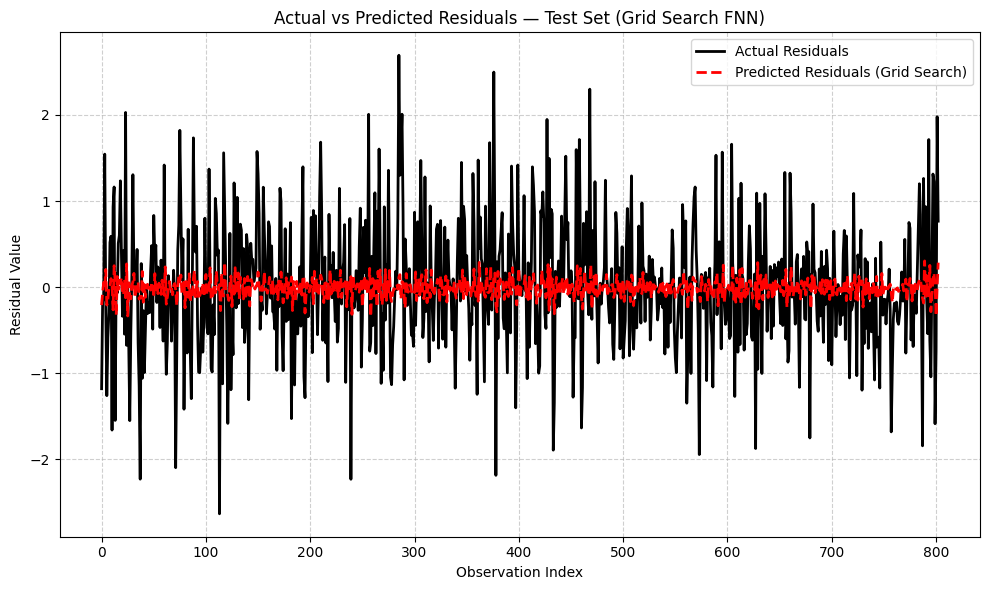

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-FNN (Grid Search) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7164
MSE:  0.5132
MAE:  0.5484
MAPE: 15.3511%
R²:   0.7964

--- Test Metrics ---
RMSE: 0.7208
MSE:  0.5196
MAE:  0.5452
MAPE: 14.7065%
R²:   0.7845


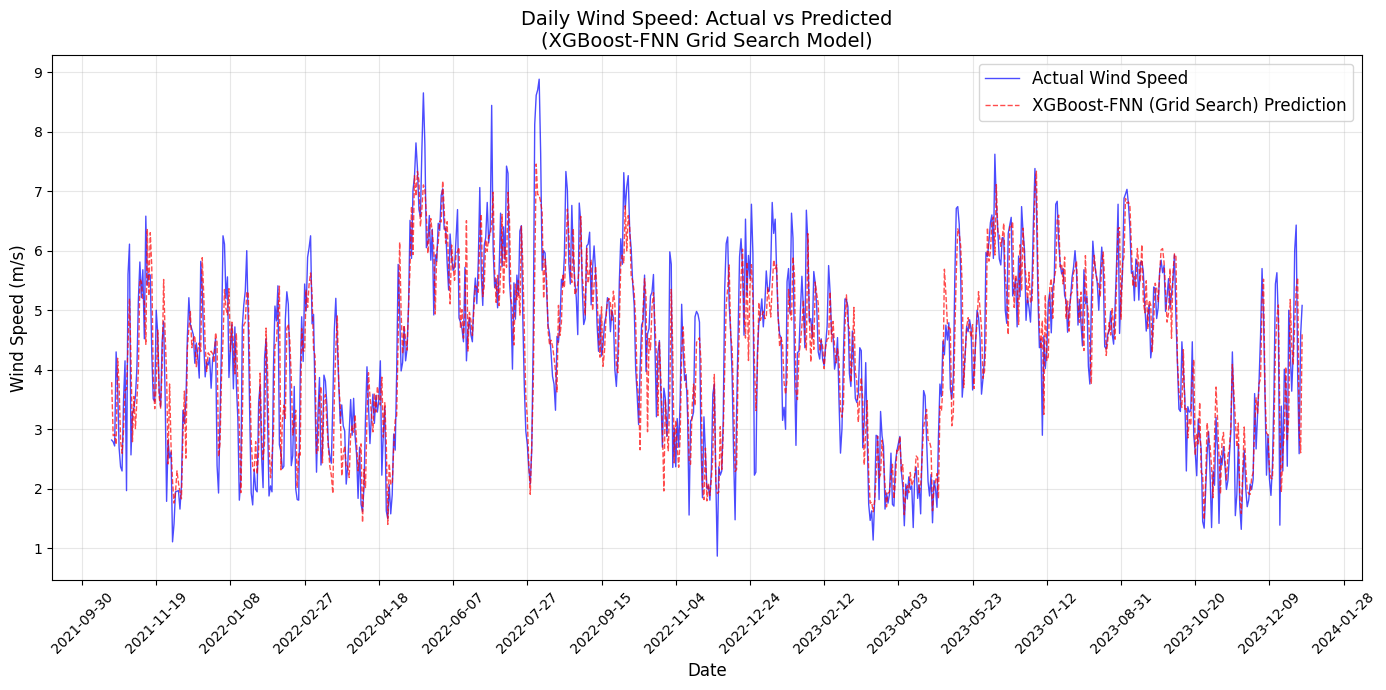

Saved to 'xgb_fnn_df_grid.csv'


In [ ]:
# =============================================================================
# Section 2 — Grid Search FNN
# Exhaustive grid search over the defined parameter grid.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_grid         = StandardScaler()
X_train_scaled_grid = scaler_grid.fit_transform(X_train_res)
X_test_scaled_grid  = scaler_grid.transform(X_test_res)

# ── Parameter grid ───────────────────────────────────────────────────────────
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'learning_rate':      ['constant', 'adaptive'],
    'alpha':              [0.0001, 0.001, 0.01],  # L2 regularisation strength
    'max_iter':           [500, 1000]
}

# ── Time series cross-validation (training data only) ───────────────────────
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled_grid, y_train_res)

best_fnn_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_grid = best_fnn_grid.predict(X_train_scaled_grid)
y_test_pred_grid  = best_fnn_grid.predict(X_test_scaled_grid)

print("\n--- Grid Search FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_grid, label="Train (FNN Grid Search)")
evaluate(y_test_res,  y_test_pred_grid,  label="Test  (FNN Grid Search)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_grid,  label='Predicted Residuals (Grid Search)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Grid Search FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 8 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). MLPRegressor.predict() can't handle NaN input, so we predict only
# on the rows where every feature is valid, and leave the rest as NaN --
# consistent with 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
predicted_residuals_fnn_grid_arr = np.full(len(X_res), np.nan)
predicted_residuals_fnn_grid_arr[full_valid_mask.values] = best_fnn_grid.predict(
    scaler_grid.transform(X_res.loc[full_valid_mask])
).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_fnn_grid'] = predicted_residuals_fnn_grid_arr

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_grid'] = (df_backup['Pred_XGB_Optuna'] +
                              df_backup['predicted_residuals_fnn_grid'])

# ── Hybrid model performance ─────────────────────────────────────────────────
# NOTE: df_backup['XGB_fnn_grid'] is NaN for the initial training block that has no
# OOF residual (Section 6/7 -- Fold 1 of TimeSeriesSplit has no preceding
# validation block). Pred_XGB_Optuna is NaN there, so those rows must be
# dropped before computing metrics -- this is exactly what was crashing with
# 'ValueError: Input contains NaN.' Test rows are unaffected (always OOS).
train_df_grid = df_backup.iloc[:split_index_res].copy()
train_df_grid = train_df_grid.dropna(subset=['XGB_fnn_grid'])
test_df_grid  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Grid Search) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_grid)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_grid = evaluate_performance(
    train_df_grid['WS10M'], train_df_grid['XGB_fnn_grid'], set_name="Train")
test_metrics_grid  = evaluate_performance(
    test_df_grid['WS10M'],  test_df_grid['XGB_fnn_grid'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_grid.index = pd.to_datetime(test_df_grid.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_grid.index, test_df_grid['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_grid.index, test_df_grid['XGB_fnn_grid'],
         label='XGBoost-FNN (Grid Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Grid Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_grid = df_backup[fnn_features + ['WS10M', 'XGB_fnn_grid']]
xgb_fnn_df_grid.to_csv('xgb_fnn_df_grid.csv', index=True)
print("Saved to 'xgb_fnn_df_grid.csv'")


## 11. FNN Residual Correction — Randomized Search Hyperparameter Optimisation


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters (Randomized Search):
{'activation': 'tanh', 'alpha': np.float64(0.001006064345328208), 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}

--- Randomized Search FNN Residual Model Evaluation ---
Train (FNN Randomized Search) MSE:  0.5132
Train (FNN Randomized Search) RMSE: 0.7164
Train (FNN Randomized Search) MAE:  0.5484
Train (FNN Randomized Search) MAPE: 166.24%
Train (FNN Randomized Search) R²:   0.0163
Test  (FNN Randomized Search) MSE:  0.5196
Test  (FNN Randomized Search) RMSE: 0.7208
Test  (FNN Randomized Search) MAE:  0.5452
Test  (FNN Randomized Search) MAPE: 169.39%
Test  (FNN Randomized Search) R²:   0.0117


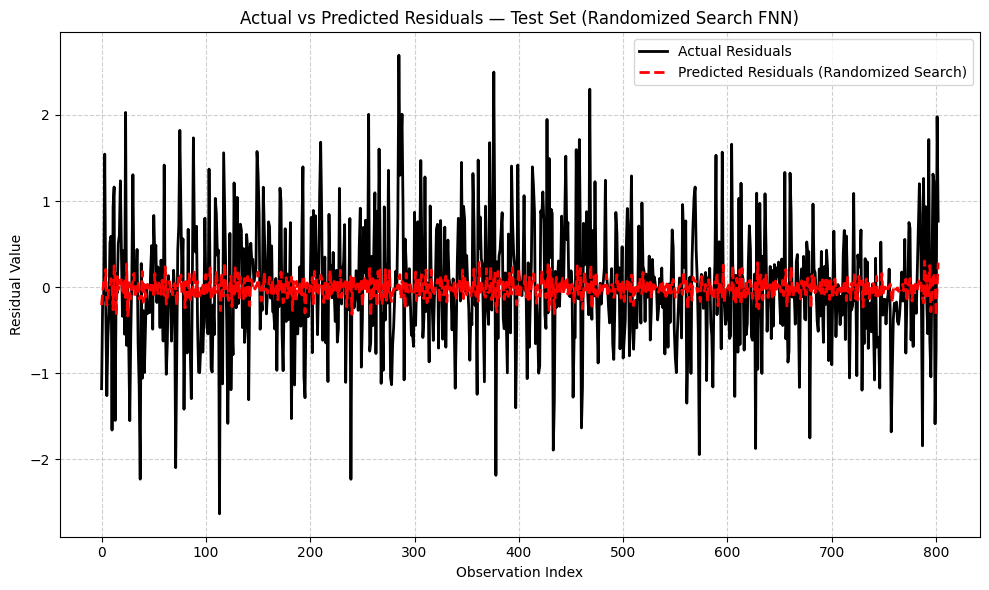

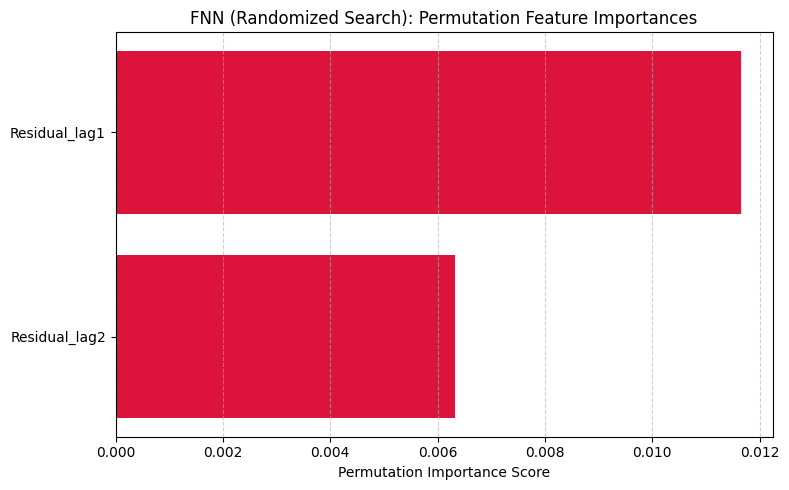

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-FNN (Randomized Search) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7164
MSE:  0.5132
MAE:  0.5484
MAPE: 15.3511%
R²:   0.7964

--- Test Metrics ---
RMSE: 0.7208
MSE:  0.5196
MAE:  0.5452
MAPE: 14.7065%
R²:   0.7845


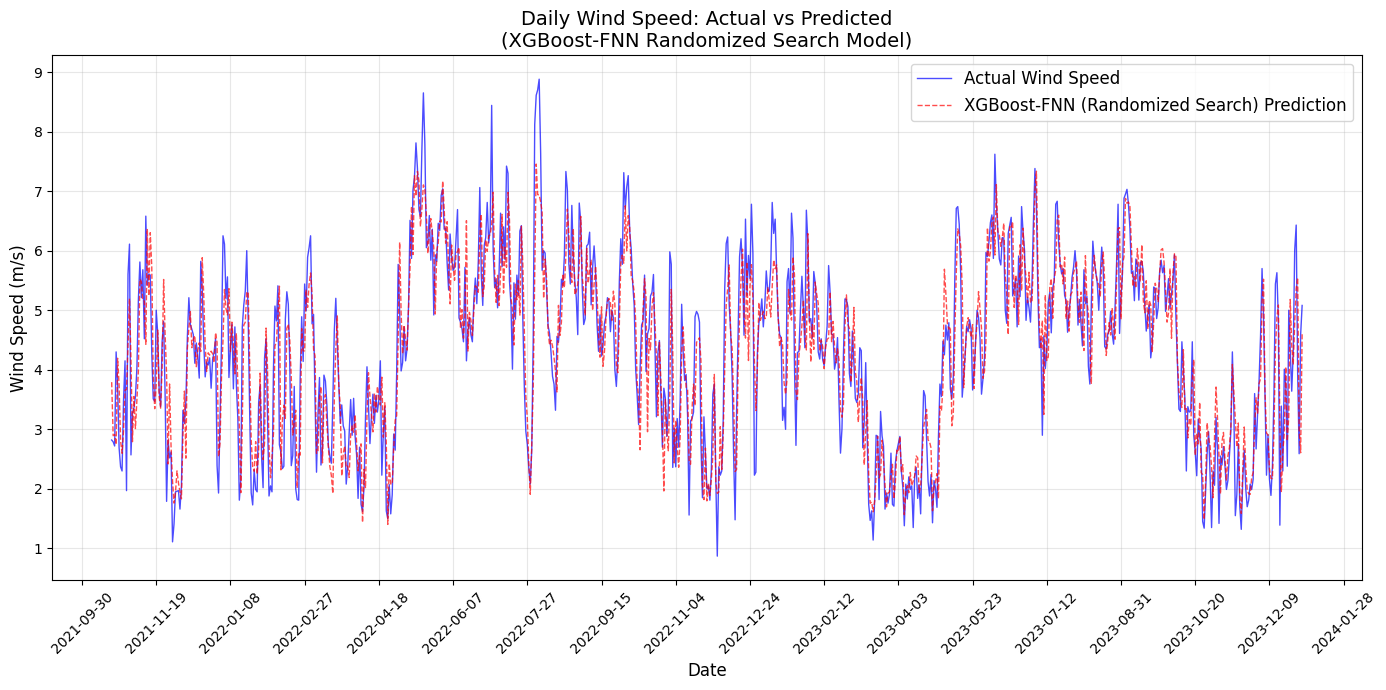

Saved to 'xgb_fnn_df_random.csv'


In [ ]:
# =============================================================================
# Section 3 — Randomized Search FNN
# Random sampling over hyperparameter distributions (30 iterations).
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_random        = StandardScaler()
X_train_scaled_rand  = scaler_random.fit_transform(X_train_res)
X_test_scaled_rand   = scaler_random.transform(X_test_res)

# ── Hyperparameter distributions ─────────────────────────────────────────────
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'alpha':              uniform(loc=0.0001, scale=0.01),  # L2 regularisation
    'learning_rate':      ['constant', 'adaptive'],
    'max_iter':           [500, 1000]
}

# ── Time series cross-validation (training data only) ───────────────────────
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=RANDOM_SEED),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

random_search.fit(X_train_scaled_rand, y_train_res)

best_fnn_random = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_rand = best_fnn_random.predict(X_train_scaled_rand)
y_test_pred_rand  = best_fnn_random.predict(X_test_scaled_rand)

print("\n--- Randomized Search FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_rand, label="Train (FNN Randomized Search)")
evaluate(y_test_res,  y_test_pred_rand,  label="Test  (FNN Randomized Search)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_rand,  label='Predicted Residuals (Randomized Search)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Randomized Search FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Permutation Feature Importance ──────────────────────────────────────────
perm_result = permutation_importance(
    best_fnn_random, X_test_scaled_rand, y_test_res,
    n_repeats=10, random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)
importance_df = pd.DataFrame({
    'Feature':    X_test_res.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='crimson')
plt.xlabel('Permutation Importance Score')
plt.title('FNN (Randomized Search): Permutation Feature Importances')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 8 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). MLPRegressor.predict() can't handle NaN input, so we predict only
# on the rows where every feature is valid, and leave the rest as NaN --
# consistent with 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
predicted_residuals_fnn_random_arr = np.full(len(X_res), np.nan)
predicted_residuals_fnn_random_arr[full_valid_mask.values] = best_fnn_random.predict(
    scaler_random.transform(X_res.loc[full_valid_mask])
).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_fnn_random'] = predicted_residuals_fnn_random_arr

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_random'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_fnn_random'])

# ── Hybrid model performance ─────────────────────────────────────────────────
# NOTE: df_backup['XGB_fnn_random'] is NaN for the initial training block that has no
# OOF residual (Section 6/7 -- Fold 1 of TimeSeriesSplit has no preceding
# validation block). Pred_XGB_Optuna is NaN there, so those rows must be
# dropped before computing metrics -- this is exactly what was crashing with
# 'ValueError: Input contains NaN.' Test rows are unaffected (always OOS).
train_df_rand = df_backup.iloc[:split_index_res].copy()
train_df_rand = train_df_rand.dropna(subset=['XGB_fnn_random'])
test_df_rand  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Randomized Search) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_rand)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_rand = evaluate_performance(
    train_df_rand['WS10M'], train_df_rand['XGB_fnn_random'], set_name="Train")
test_metrics_rand  = evaluate_performance(
    test_df_rand['WS10M'],  test_df_rand['XGB_fnn_random'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_rand.index = pd.to_datetime(test_df_rand.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_rand.index, test_df_rand['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_rand.index, test_df_rand['XGB_fnn_random'],
         label='XGBoost-FNN (Randomized Search) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Randomized Search Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_random = df_backup[fnn_features + ['WS10M', 'XGB_fnn_random']]
xgb_fnn_df_random.to_csv('xgb_fnn_df_random.csv', index=True)
print("Saved to 'xgb_fnn_df_random.csv'")


## 12. FNN Residual Correction — Optuna Bayesian Optimisation



Best Trial:
FrozenTrial(number=17, state=<TrialState.COMPLETE: 1>, values=[0.5235828276577202], datetime_start=datetime.datetime(2026, 8, 2, 2, 53, 53, 526333), datetime_complete=datetime.datetime(2026, 8, 2, 2, 53, 54, 129674), params={'n_layers': 1, 'n_units_l0': 107, 'activation': 'tanh', 'alpha': 0.0001411433462576514, 'learning_rate': 'constant'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_l0': IntDistribution(high=150, log=False, low=20, step=1), 'activation': CategoricalDistribution(choices=('relu', 'tanh')), 'alpha': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'learning_rate': CategoricalDistribution(choices=('constant', 'adaptive'))}, trial_id=17, value=None)

Best Parameters (Optuna):
{'n_layers': 1, 'n_units_l0': 107, 'activation': 'tanh', 'alpha': 0.0001411433462576514, 'learning_rate': 'constant'}

--- Optuna FNN Residual Model Evaluation ---
Train (FNN Op

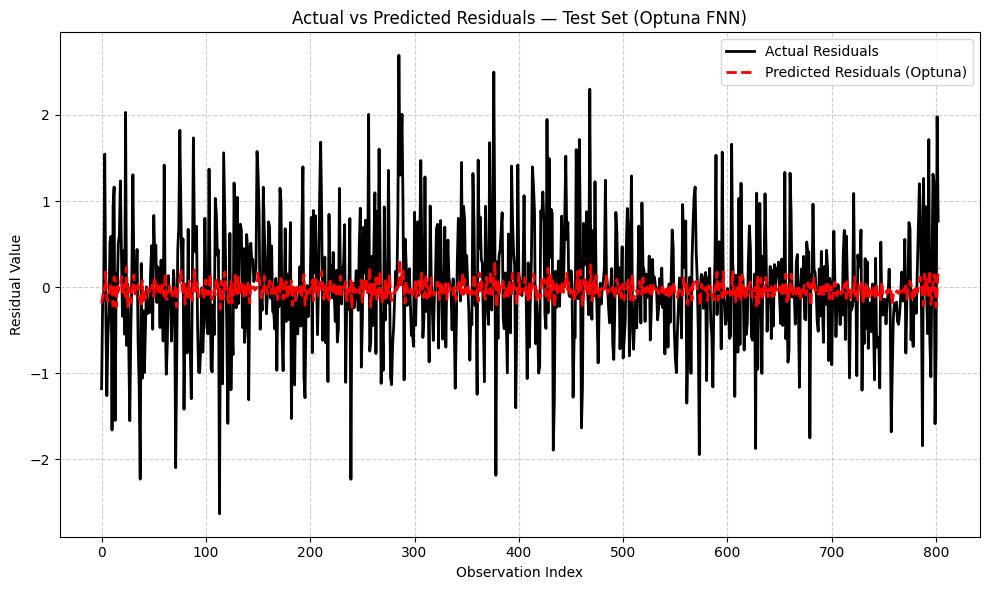

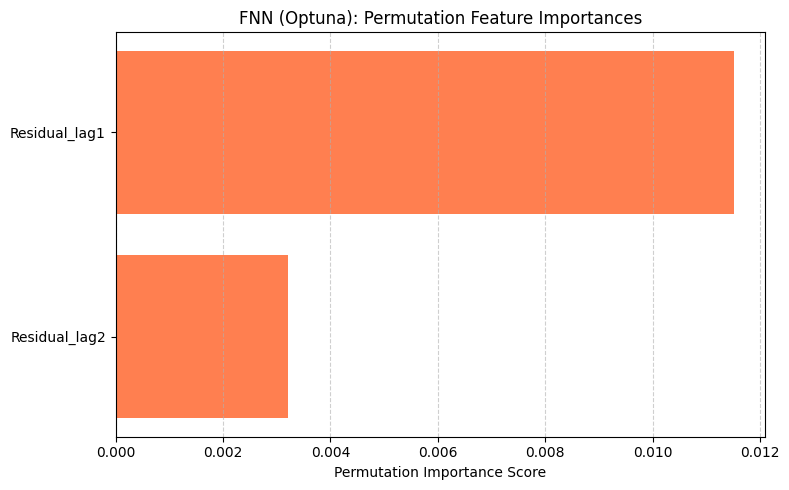

Full-dataset residual predictions: 3476 / 4015 rows (NaN elsewhere -- missing lag feature(s))

=== Hybrid XGB-FNN (Optuna) Performance on WS10M ===
(Train metrics computed on 2673 rows -- initial OOF-uncovered block excluded)

--- Train Metrics ---
RMSE: 0.7157
MSE:  0.5123
MAE:  0.5475
MAPE: 15.2283%
R²:   0.7967

--- Test Metrics ---
RMSE: 0.7209
MSE:  0.5197
MAE:  0.5426
MAPE: 14.5498%
R²:   0.7845


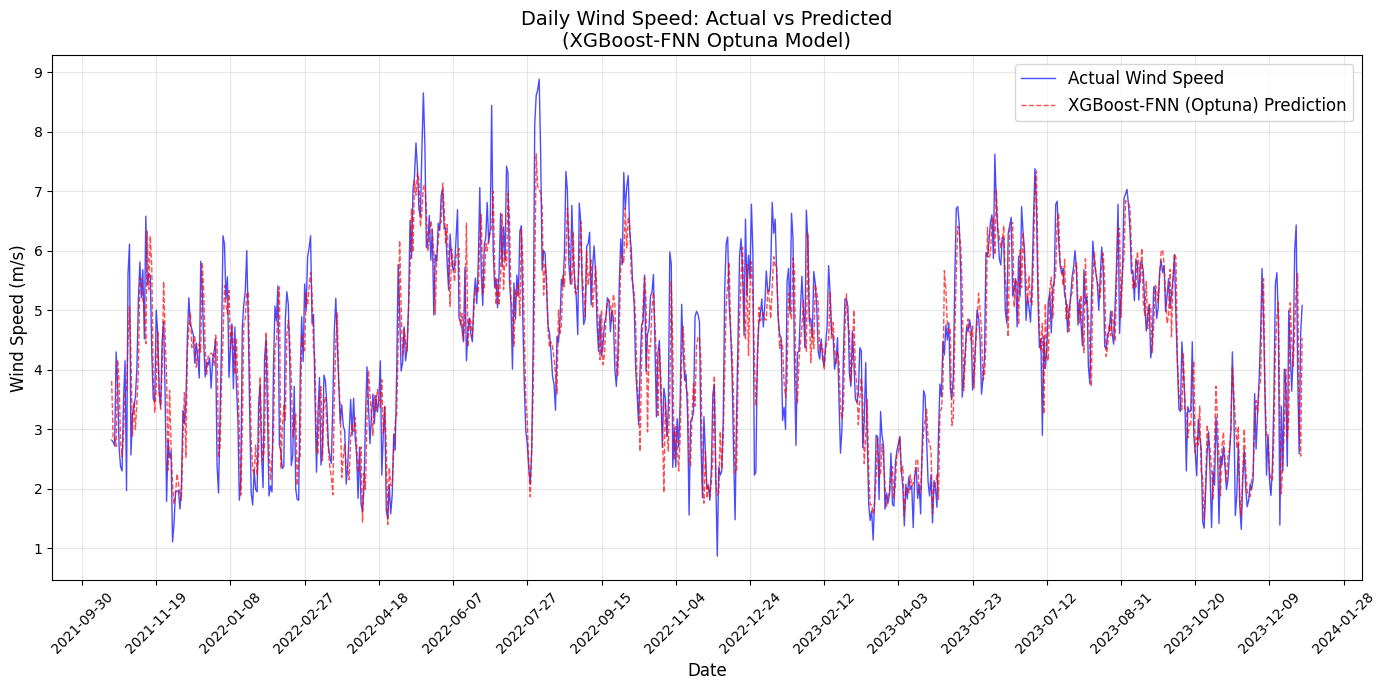

Saved to 'xgb_fnn_df_optuna.csv'


In [ ]:
# =============================================================================
# Section 4 — Optuna FNN
# Bayesian (TPE) hyperparameter search over architecture and regularisation.
# TimeSeriesSplit (5 folds) is applied exclusively on training data.
# FIX: Optuna objective uses the pre-scaled training array (X_train_scaled_opt)
#      to ensure the FNN sees the same scaled input as the final model.
# =============================================================================

# ── Scaling (fit on training data only — no leakage) ────────────────────────
scaler_optuna       = StandardScaler()
X_train_scaled_opt  = scaler_optuna.fit_transform(X_train_res)
X_test_scaled_opt   = scaler_optuna.transform(X_test_res)

# ── Optuna objective function ────────────────────────────────────────────────
def fnn_objective(trial):
    """
    Objective function for Optuna Bayesian optimisation.
    Uses pre-scaled training data and TimeSeriesSplit for cross-validation.
    """
    # Suggest architecture: number of layers and units per layer
    n_layers           = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 20, 150)
        for i in range(n_layers)
    )

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation':    trial.suggest_categorical('activation',
                                                   ['relu', 'tanh']),
        'solver':        'adam',  # fixed
        'alpha':         trial.suggest_float('alpha', 1e-5, 1e-2, log=True),  # L2 regularisation
        'learning_rate': trial.suggest_categorical('learning_rate',
                                                   ['constant', 'adaptive']),
        'max_iter':      1000,
        'random_state':  RANDOM_SEED
    }

    # Time series cross-validation on scaled training data only
    tscv       = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X_train_scaled_opt):
        # Use pre-scaled numpy arrays (avoids double-scaling / data leakage)
        X_t = X_train_scaled_opt[train_idx]
        X_v = X_train_scaled_opt[val_idx]
        y_t = y_train_res.iloc[train_idx]
        y_v = y_train_res.iloc[val_idx]

        model = MLPRegressor(**params)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        mse_scores.append(mean_squared_error(y_v, preds))

    return np.mean(mse_scores)

# ── Create and run Optuna study ──────────────────────────────────────────────
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
# max 30 trials or 10 minutes, whichever comes first
study.optimize(fnn_objective, n_trials=30, timeout=600)

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# ── Reconstruct architecture from best Optuna parameters ────────────────────
best_params_opt        = study.best_params
hidden_layer_sizes_opt = tuple(
    best_params_opt[f'n_units_l{i}']
    for i in range(best_params_opt['n_layers'])
)

# ── Refit final model on full training data ──────────────────────────────────
final_fnn_optuna = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes_opt,
    activation=best_params_opt['activation'],
    solver='adam',
    alpha=best_params_opt['alpha'],
    learning_rate=best_params_opt['learning_rate'],
    max_iter=1000,
    random_state=RANDOM_SEED
)
final_fnn_optuna.fit(X_train_scaled_opt, y_train_res)

# ── Residual model evaluation ────────────────────────────────────────────────
y_train_pred_opt = final_fnn_optuna.predict(X_train_scaled_opt)
y_test_pred_opt  = final_fnn_optuna.predict(X_test_scaled_opt)

print("\n--- Optuna FNN Residual Model Evaluation ---")
evaluate(y_train_res, y_train_pred_opt, label="Train (FNN Optuna)")
evaluate(y_test_res,  y_test_pred_opt,  label="Test  (FNN Optuna)")

# Visualise test-set residual predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_res.values, label='Actual Residuals',
         color='black', linewidth=2)
plt.plot(y_test_pred_opt,   label='Predicted Residuals (Optuna)',
         color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Residuals — Test Set (Optuna FNN)')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Permutation Feature Importance ──────────────────────────────────────────
perm_result_opt = permutation_importance(
    final_fnn_optuna, X_test_scaled_opt, y_test_res,
    n_repeats=10, random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)
importance_df_opt = pd.DataFrame({
    'Feature':    X_test_res.columns,
    'Importance': perm_result_opt.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df_opt['Feature'], importance_df_opt['Importance'],
         color='coral')
plt.xlabel('Permutation Importance Score')
plt.title('FNN (Optuna): Permutation Feature Importances')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Predict residuals on full dataset ────────────────────────────────────────
# NOTE: X_res (unlike X_train_res/X_test_res) is NOT pre-filtered for NaNs --
# it still contains the rows Section 8 dropped (Fold 1's OOF-uncovered
# training block, plus the first 1-2 rows with no Residual_lag1/lag2 to look
# back on). MLPRegressor.predict() can't handle NaN input, so we predict only
# on the rows where every feature is valid, and leave the rest as NaN --
# consistent with 'Pred_XGB_Optuna' already being NaN for those same rows.
full_valid_mask = X_res.notna().all(axis=1)
predicted_residuals_fnn_optuna_arr = np.full(len(X_res), np.nan)
predicted_residuals_fnn_optuna_arr[full_valid_mask.values] = final_fnn_optuna.predict(
    scaler_optuna.transform(X_res.loc[full_valid_mask])
).flatten()
print(f"Full-dataset residual predictions: {int(full_valid_mask.sum())} / "
      f"{len(X_res)} rows (NaN elsewhere -- missing lag feature(s))")

df_backup['predicted_residuals_fnn_optuna'] = predicted_residuals_fnn_optuna_arr

# ── Hybrid prediction: XGB + FNN residual correction ────────────────────────
df_backup['XGB_fnn_optuna'] = (df_backup['Pred_XGB_Optuna'] +
                                df_backup['predicted_residuals_fnn_optuna'])

# ── Hybrid model performance ─────────────────────────────────────────────────
# NOTE: df_backup['XGB_fnn_optuna'] is NaN for the initial training block that has no
# OOF residual (Section 6/7 -- Fold 1 of TimeSeriesSplit has no preceding
# validation block). Pred_XGB_Optuna is NaN there, so those rows must be
# dropped before computing metrics -- this is exactly what was crashing with
# 'ValueError: Input contains NaN.' Test rows are unaffected (always OOS).
train_df_opt = df_backup.iloc[:split_index_res].copy()
train_df_opt = train_df_opt.dropna(subset=['XGB_fnn_optuna'])
test_df_opt  = df_backup.iloc[split_index_res:].copy()

print("\n=== Hybrid XGB-FNN (Optuna) Performance on WS10M ===")
print(f"(Train metrics computed on {len(train_df_opt)} rows -- initial "
      f"OOF-uncovered block excluded)")
train_metrics_opt = evaluate_performance(
    train_df_opt['WS10M'], train_df_opt['XGB_fnn_optuna'], set_name="Train")
test_metrics_opt  = evaluate_performance(
    test_df_opt['WS10M'],  test_df_opt['XGB_fnn_optuna'],  set_name="Test")

# ── Visualise test-set predictions ──────────────────────────────────────────
test_df_opt.index = pd.to_datetime(test_df_opt.index)
plt.figure(figsize=(14, 7))
plt.plot(test_df_opt.index, test_df_opt['WS10M'],
         label='Actual Wind Speed', color='blue', alpha=0.7, linewidth=1)
plt.plot(test_df_opt.index, test_df_opt['XGB_fnn_optuna'],
         label='XGBoost-FNN (Optuna) Prediction',
         color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.title('Daily Wind Speed: Actual vs Predicted\n(XGBoost-FNN Optuna Model)',
          fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save results to CSV
xgb_fnn_df_optuna = df_backup[fnn_features + ['WS10M', 'XGB_fnn_optuna']]
xgb_fnn_df_optuna.to_csv('xgb_fnn_df_optuna.csv', index=True)
print("Saved to 'xgb_fnn_df_optuna.csv'")


In [ ]:
# ── Export test-set actuals and predictions for Diebold-Mariano test ─────────
dm_test_df = test_df_opt[['WS10M', 'XGB_fnn_optuna']].copy()
dm_test_df['residuals_XGB_FNN_Optuna'] = dm_test_df['WS10M'] - dm_test_df['XGB_fnn_optuna']
dm_test_df.to_csv('dm_test_xgb_fnn_optuna.csv', index=True)
print("Saved to 'dm_test_xgb_fnn_optuna.csv'")

Saved to 'dm_test_xgb_fnn_optuna.csv'


## 13. Comprehensive Performance Comparison Across All Methods


In [ ]:
# =============================================================================
# Summary comparison of all four XGBoost-FNN hybrid model variants.
# Method labels: "Original Model", "Grid Search", "Randomized Search", "Optuna"
# =============================================================================

actual = df_backup['WS10M']

# Map human-readable method names to dataframe column names
methods_map = {
    'Original Model':    'XGB_fnn_original',
    'Grid Search':       'XGB_fnn_grid',
    'Randomized Search': 'XGB_fnn_random',
    'Optuna':            'XGB_fnn_optuna'
}

split_idx    = int(0.8 * len(df_backup))
train_actual = actual.iloc[:split_idx]
test_actual  = actual.iloc[split_idx:]

# NOTE: the initial training block has no OOF residual (Section 6/7), so
# every 'XGB_fnn_*' column is NaN there. Those rows are dropped per-method
# before computing metrics -- otherwise mean_squared_error etc. would raise
# or silently propagate NaN into the comparison table. Test rows are
# unaffected (they were always out-of-sample).
results = []
for method_name, col_name in methods_map.items():
    pred       = df_backup[col_name]
    train_pred = pred.iloc[:split_idx].dropna()
    train_act  = train_actual.loc[train_pred.index]
    test_pred  = pred.iloc[split_idx:]
    test_act   = test_actual

    results.append({
        'Method':         method_name,
        'Train rows':     len(train_pred),
        'Train MSE':      mean_squared_error(train_act, train_pred),
        'Test MSE':       mean_squared_error(test_act,  test_pred),
        'Train MAE':      mean_absolute_error(train_act, train_pred),
        'Test MAE':       mean_absolute_error(test_act,  test_pred),
        'Train RMSE':     np.sqrt(mean_squared_error(train_act, train_pred)),
        'Test RMSE':      np.sqrt(mean_squared_error(test_act,  test_pred)),
        'Train MAPE (%)': np.mean(np.abs((train_act - train_pred) / train_act)) * 100,
        'Test MAPE (%)':  np.mean(np.abs((test_act  - test_pred)  / test_act))  * 100,
        'Train R²':       r2_score(train_act, train_pred),
        'Test R²':        r2_score(test_act,  test_pred)
    })

results_df = pd.DataFrame(results)
print("\n=== XGBoost-FNN Hybrid Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Save the full comparison to CSV
results_df.to_csv('xgb_fnn_all_models_performance.csv', index=False)
print("\nSaved to 'xgb_fnn_all_models_performance.csv'")

# ── Plotly summary table ─────────────────────────────────────────────────────
numeric_cols = [c for c in results_df.columns if c != 'Method']
display_df   = results_df.copy()
for col in numeric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.6f}")

fig_summary = go.Figure(go.Table(
    header=dict(
        values=[f'<b>{c}</b>' for c in results_df.columns],
        fill_color='steelblue',
        font=dict(color='white', size=11),
        align='center'
    ),
    cells=dict(
        values=[display_df[c] for c in display_df.columns],
        fill_color=[['lightcyan' if i % 2 == 0 else 'white'
                     for i in range(len(display_df))]],
        align='center'
    )
))
fig_summary.update_layout(
    title="XGBoost-FNN Hybrid Models — Full Performance Comparison",
    template="plotly_white",
    height=300
)
fig_summary.show()



=== XGBoost-FNN Hybrid Model Performance Comparison ===
           Method  Train rows  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model        2673   0.507299  0.517639   0.545934  0.545055    0.712250   0.719471       15.336320      14.822203  0.798715 0.785341
      Grid Search        2673   0.513222  0.519599   0.548388  0.545191    0.716395   0.720832       15.351121      14.706467  0.796365 0.784528
Randomized Search        2673   0.513222  0.519598   0.548388  0.545191    0.716395   0.720832       15.351118      14.706463  0.796365 0.784528
           Optuna        2673   0.512259  0.519722   0.547547  0.542622    0.715723   0.720918       15.228289      14.549779  0.796747 0.784477

Saved to 'xgb_fnn_all_models_performance.csv'
